In [2]:
!rm -rf InkubaLM-Challenge
!git clone https://github.com/melissafasol/InkubaLM-Challenge.git
%cd InkubaLM-Challenge

Cloning into 'InkubaLM-Challenge'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 299 (delta 59), reused 39 (delta 16), pack-reused 202 (from 1)
Receiving objects: 100% (299/299), 1.04 MiB | 15.17 MiB/s, done.
Resolving deltas: 100% (186/186), done.
/content/InkubaLM-Challenge


In [3]:
!git checkout refactor-src-structure
!git pull

Branch 'refactor-src-structure' set up to track remote branch 'refactor-src-structure' from 'origin'.
Switched to a new branch 'refactor-src-structure'
Already up to date.


In [4]:
!pip install datasets
!pip install transformers datasets peft trl accelerate bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [5]:
import sys
sys.path.append("..")  # Add parent directory to the path

import os
from typing import List
from pathlib import Path
import numpy as np

# DO NOT EDIT
# create submission file
import pandas as pd
from huggingface_hub import login
from transformers import (
    AutoTokenizer,
)

from utils import (
    model_function,
    eval
    )

from src import (
    data_utils,
    model_utils,
    inference,
    prompts,
    evaluation,
    data_augment
    )

import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel
from datasets import load_dataset, concatenate_datasets, Dataset, Value, DatasetDict

from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM
from peft import PeftModel, PeftConfig
from sklearn.model_selection import train_test_split


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#os.environ["TOKENIZERS_PARALLELISM"] = "false"

from huggingface_hub import login

try:
    from google.colab import userdata

    # Note: `userdata.get` is a Colab API. If you're not using Colab, set the env
    # vars as appropriate for your system.
    # userdata.get("HF_TOKEN") indicates that the name of the token in the Colab env is HF_TOKEN
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
except:
    os.environ["HF_TOKEN"] = "----"

login(token=os.environ["HF_TOKEN"])

token = os.environ["HF_TOKEN"]
if token == "----":
    print("⚠️ Warning: No Hugging Face token found. Some models may not load.")
else:
    login(token=token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Load Base Model and Run Inference on Test Set for Baseline Performance

In [8]:
model_name = "lelapa/InkubaLM-0.4B"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=os.environ["HF_TOKEN"])
model = model_function.load_model(model_name)

/usr/local/lib/python3.11/dist-packages/transformers/models/auto/tokenization_auto.py:862: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/960 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/991k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.95M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/763 [00:00<?, ?B/s]

vulavulaslm.py:   0%|          | 0.00/42.2k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/lelapa/InkubaLM-0.4B:
- vulavulaslm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/2.66G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [9]:
BASE_PROMPT = "Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.\n\n ### Instruction: {}\n\n ### Response: "
sent_instruction = "Please identify the sentiment reflected in this text based on the following guidelines: Positive: if a text implies positive sentiment, attitude, and emotional state. Negative: if a text implies negative sentiment or emotion. Neutral: if a text does not imply positive or negative language directly or indirectly. Provide sentiment labels only"

In [ ]:
print("# Loading datasets")
sentiment_train_df = pd.read_parquet("hf://datasets/lelapa/SentimentTrain/data/train-00000-of-00001.parquet")

hau_dataset = Dataset.from_pandas(
    sentiment_train_df[sentiment_train_df['langs']=='hausa']
)
swa_dataset = Dataset.from_pandas(
    sentiment_train_df[sentiment_train_df['langs']=='swahili']
)

# If you need a DatasetDict to mimic the Hugging Face structure
dataset_dict = DatasetDict({
    "swahili": swa_dataset,
    "hausa": hau_dataset
})


# for swahili
model_function.main(
    model,
    tokenizer,
    BASE_PROMPT,
    sample_size=3,
    max_new_tokens=15,
    task_instruction=sent_instruction,
    dataset=swa_dataset,
    csv_file_path=os.path.join(
        output_path,
        "swa_sent_prediction_dev.csv"
    ),
    custom_instruct=False,
)



# Loading datasets


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


In [ ]:
# for hausa
model_function.main(
    model,
    tokenizer,
    BASE_PROMPT,
    sample_size=3,
    task_instruction=sent_instruction,
    dataset=hau_dataset,
    csv_file_path=os.path.join(
        output_path,
        "hau_sent_prediction_dev.csv"
    ),
    max_new_tokens=15,
    custom_instruct=False,
)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


In [ ]:
from sklearn.utils import shuffle
test_dev = pd.concat([mt_train_og, hau_dataset_mt], axis=0, ignore_index=True)
test_dev = shuffle(test_dev, random_state=42).reset_index(drop=True)

In [ ]:
hau_dataset_mt

,ID,task,langs,data_source,instruction,inputs,targets
0,opus_hausa_81,mmt,eng-hau,opus100,translate the following from English into hausa.,and we have created for them of the like there...,"kuma muka halitta musu, daga irinsa, abin da s..."
1,opus_hausa_218,mmt,eng-hau,opus100,translate the following from English into hausa.,"""come back to your lord, well-pleased (yoursel...","ka koma zuwa ga ubangijinka, alhãli kana mai y..."
2,opus_hausa_55,mmt,eng-hau,opus100,translate the following from English into hausa.,they said: thou art but one of the bewitched;,"suka ce: ""kai daga mãsu sihiri kurum kake."""
3,opus_hausa_598,mmt,eng-hau,opus100,translate the following from English into hausa.,welcome to the gnome desktop,barka da zuwa kwamfyutan tebur na gnome
4,opus_hausa_264,mmt,eng-hau,opus100,translate the following from English into hausa.,the hour of resurrection is coming. i have wil...,"""lalle ne sa'a mai zuwa ce, lnã kusa da in ɓõy..."
...,...,...,...,...,...,...,...
605,opus_hausa_71,mmt,eng-hau,opus100,translate the following from English into hausa.,as such we shall deal with the evildoers.,"lalle mũ, kamar haka muke aikatãwa game, da mã..."
606,opus_hausa_106,mmt,eng-hau,opus100,translate the following from English into hausa.,"go, you and your brother, with my signs, and d...","""ka tafi kai da ɗan'uwanka game da ãyõyina, ku..."
607,opus_hausa_270,mmt,eng-hau,opus100,translate the following from English into hausa.,when their brother lut said to them: will you ...,"a lõkacin da ɗan'uwansu, lũɗu ya ce musu, ""bã ..."
608,opus_hausa_435,mmt,eng-hau,opus100,translate the following from English into hausa.,"then they (the worshippers of idols) came, tow...","sai suka fuskanto zuwa gare shi, sunã gaggãwa."


## MT baseline

In [17]:
import os
output_path = "/content/drive/MyDrive/InkubaLM-Challenge/Output/baseline_performance/datasets"
os.makedirs(output_path, exist_ok=True)

print(os.path.exists(output_path))  # Should return True
print(output_path)

True
/content/drive/MyDrive/InkubaLM-Challenge/Output/baseline_performance/datasets


In [11]:
import random

# Sample English sentences for everyday conversation (can be modified later)
base_sentences = [
    "Good morning! How did you sleep?",
    "I'm going to the market. Do you want anything?",
    "What time is the meeting today?",
    "Can you help me with this?",
    "The weather is very hot today.",
    "I need to call my mother.",
    "Have you seen my keys?",
    "We should leave early to avoid traffic.",
    "I'm feeling a bit tired.",
    "Do you want to have lunch together?",
    "I like listening to music while I work.",
    "Can you pick up the kids from school?",
    "Don't forget to lock the door.",
    "Let's meet at the cafe around 4 PM.",
    "I'm learning how to cook rice perfectly.",
    "He always forgets his wallet.",
    "Would you like some tea or coffee?",
    "I'm watching a really good movie.",
    "This song reminds me of home.",
    "Can I borrow your pen?",
]

# Hausa translations (GPT-style, manually curated)
base_translations = [
    "Ina kwana! Yaya ka kwana?",
    "Zan je kasuwa. Kana bukatar wani abu?",
    "Karfe nawa taron yake yau?",
    "Za ka iya taimaka min da wannan?",
    "Yau rana tana da zafi sosai.",
    "Ina bukatar kiran mahaifiyata.",
    "Ka ga makullina?",
    "Ya kamata mu tafi da wuri domin gujewa cunkoso.",
    "Ina jin gajiya kadan.",
    "Kana son mu ci abincin rana tare?",
    "Ina jin dadin sauraron kiɗa yayin aiki.",
    "Za ka iya dauko yara daga makaranta?",
    "Kada ka manta rufe kofa.",
    "Mu hadu a gidan shayi misalin karfe 4 na yamma.",
    "Ina koyon yadda ake dafa shinkafa sosai.",
    "Yana yawan mantawa da walat dinsa.",
    "Kana son shayi ko kofi?",
    "Ina kallon fim mai kyau sosai.",
    "Wannan waƙar tana tuna min da gida.",
    "Zan iya amfani da alƙalanka?",
]

# Bootstrap 200 examples using these as base
num_samples = 200
synthetic_data = []

for i in range(num_samples):
    idx = random.randint(0, len(base_sentences) - 1)
    synthetic_data.append({
        "ID": f"bootstrap_hausa_convo_{i}",
        "task": "mmt",
        "langs": "eng-hau",
        "data_source": "synthetic",
        "instruction": "translate the following from English into Hausa.",
        "inputs": base_sentences[idx],
        "targets": base_translations[idx],
    })

df_synthetic_hausa = pd.DataFrame(synthetic_data)

In [12]:
# Updated cleaner Hausa translations and matching English prompts
base_sentences = [
    "Good morning! How did you sleep?",
    "I'm going to the market. Do you want anything?",
    "What time is the meeting today?",
    "Can you help me with this?",
    "The weather is very hot today.",
    "I need to call my mother.",
    "Have you seen my keys?",
    "We should leave early to avoid traffic.",
    "I'm feeling a bit tired.",
    "Do you want to have lunch together?",
    "I like listening to music while I work.",
    "Can you pick up the kids from school?",
    "Don't forget to lock the door.",
    "Let's meet at the cafe around 4 PM.",
    "I'm learning how to cook rice perfectly.",
    "He always forgets his wallet.",
    "Would you like some tea or coffee?",
    "I'm watching a really good movie.",
    "This song reminds me of home.",
    "Can I borrow your pen?",
]

# Manually verified clean Hausa translations (no corrupted characters, well-formed)
base_translations = [
    "Ina kwana! Ka tashi lafiya?",
    "Zan je kasuwa. Kana buƙatar wani abu?",
    "Karfe nawa taron yake yau?",
    "Za ka iya taimaka min da wannan?",
    "Yau rana tana da zafi sosai.",
    "Ina bukatar in kira mahaifiyata.",
    "Ka ga makullina?",
    "Ya kamata mu tafi da wuri domin kaucewa cunkoso.",
    "Ina jin kaɗan gajiya.",
    "Kana son muyi cin abincin rana tare?",
    "Ina son sauraron waƙa yayin da nake aiki.",
    "Za ka iya ɗauko yara daga makaranta?",
    "Kada ka manta rufe ƙofa.",
    "Mu haɗu a gidan shayi da misalin karfe huɗu.",
    "Ina koyon yadda ake dafa shinkafa yadda ya kamata.",
    "Yana yawan mantawa da walat dinsa.",
    "Kana son shayi ko kofi?",
    "Ina kallon fim mai kyau sosai.",
    "Waƙar nan tana tuna min gida.",
    "Zan iya amfani da alƙalanka?",
]

# Generate 200 clean synthetic Hausa MT examples
num_samples = 200
synthetic_data = []

for i in range(num_samples):
    idx = random.randint(0, len(base_sentences) - 1)
    synthetic_data.append({
        "ID": f"bootstrap_hausa_convo_clean_{i}",
        "task": "mmt",
        "langs": "eng-hau",
        "data_source": "synthetic",
        "instruction": "translate the following from English into Hausa.",
        "inputs": base_sentences[idx],
        "targets": base_translations[idx],
    })

df_clean_hausa = pd.DataFrame(synthetic_data)

In [13]:
import random
import pandas as pd

# English - Swahili conversation examples
base_sentences = [
    "Good morning! How did you sleep?",
    "I'm going to the market. Do you want anything?",
    "What time is the meeting today?",
    "Can you help me with this?",
    "The weather is very hot today.",
    "I need to call my mother.",
    "Have you seen my keys?",
    "We should leave early to avoid traffic.",
    "I'm feeling a bit tired.",
    "Do you want to have lunch together?",
    "I like listening to music while I work.",
    "Can you pick up the kids from school?",
    "Don't forget to lock the door.",
    "Let's meet at the cafe around 4 PM.",
    "I'm learning how to cook rice perfectly.",
    "He always forgets his wallet.",
    "Would you like some tea or coffee?",
    "I'm watching a really good movie.",
    "This song reminds me of home.",
    "Can I borrow your pen?",
]

# Swahili translations
base_translations = [
    "Habari za asubuhi! Ulilala vizuri?",
    "Nakwenda sokoni. Unahitaji kitu chochote?",
    "Mkutano ni saa ngapi leo?",
    "Unaweza kunisaidia na hili?",
    "Hali ya hewa ni ya joto sana leo.",
    "Nahitaji kumpigia mama simu.",
    "Umeona funguo zangu?",
    "Tupaswa kuondoka mapema kuepuka msongamano.",
    "Najisikia nimechoka kidogo.",
    "Unataka kula chakula cha mchana pamoja?",
    "Napenda kusikiliza muziki ninapofanya kazi.",
    "Unaweza kuwachukua watoto shuleni?",
    "Usisahau kufunga mlango.",
    "Tukutane kwenye mgahawa saa kumi alasiri.",
    "Ninajifunza kupika wali vizuri.",
    "Husahau pochi yake kila mara.",
    "Unataka chai au kahawa?",
    "Ninatazama filamu nzuri sana.",
    "Wimbo huu unanifanya nikumbuke nyumbani.",
    "Naweza kukopa kalamu yako?",
]

# Create synthetic Swahili MT examples
num_samples = 200
synthetic_data = []

for i in range(num_samples):
    idx = random.randint(0, len(base_sentences) - 1)
    synthetic_data.append({
        "ID": f"bootstrap_swahili_convo_{i}",
        "task": "mmt",
        "langs": "eng-swa",
        "data_source": "synthetic",
        "instruction": "translate the following from English into Swahili.",
        "inputs": base_sentences[idx],
        "targets": base_translations[idx],
    })

df_synthetic_swahili = pd.DataFrame(synthetic_data)

In [14]:
df_synthetic_swahili

,ID,task,langs,data_source,instruction,inputs,targets
0,bootstrap_swahili_convo_0,mmt,eng-swa,synthetic,translate the following from English into Swah...,I'm learning how to cook rice perfectly.,Ninajifunza kupika wali vizuri.
1,bootstrap_swahili_convo_1,mmt,eng-swa,synthetic,translate the following from English into Swah...,Can I borrow your pen?,Naweza kukopa kalamu yako?
2,bootstrap_swahili_convo_2,mmt,eng-swa,synthetic,translate the following from English into Swah...,Can you pick up the kids from school?,Unaweza kuwachukua watoto shuleni?
3,bootstrap_swahili_convo_3,mmt,eng-swa,synthetic,translate the following from English into Swah...,Have you seen my keys?,Umeona funguo zangu?
4,bootstrap_swahili_convo_4,mmt,eng-swa,synthetic,translate the following from English into Swah...,Have you seen my keys?,Umeona funguo zangu?
...,...,...,...,...,...,...,...
195,bootstrap_swahili_convo_195,mmt,eng-swa,synthetic,translate the following from English into Swah...,We should leave early to avoid traffic.,Tupaswa kuondoka mapema kuepuka msongamano.
196,bootstrap_swahili_convo_196,mmt,eng-swa,synthetic,translate the following from English into Swah...,Let's meet at the cafe around 4 PM.,Tukutane kwenye mgahawa saa kumi alasiri.
197,bootstrap_swahili_convo_197,mmt,eng-swa,synthetic,translate the following from English into Swah...,I'm feeling a bit tired.,Najisikia nimechoka kidogo.
198,bootstrap_swahili_convo_198,mmt,eng-swa,synthetic,translate the following from English into Swah...,Have you seen my keys?,Umeona funguo zangu?


In [17]:
import importlib
import src.data_augment
import src.evaluation
import src.model_utils
importlib.reload(src.data_augment)
importlib.reload(src.evaluation)
importlib.reload(src.model_utils)

<module 'src.model_utils' from '/content/InkubaLM-Challenge/src/model_utils.py'>

In [23]:
# Load the Swahili dataset from a local CSV file
mt_train = pd.read_parquet("hf://datasets/lelapa/MTTrain/data/train-00000-of-00001.parquet")
hau_dataset_pd = mt_train.loc[mt_train['langs'] == 'eng-hau']
data_augment.preprocess_dataframe(hau_dataset_pd,target_language='hausa')


,ID,task,langs,data_source,instruction,inputs,targets
0,ID_5e3d2251_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,this is possible because the on-demand applica...,wannan yana yiwuwa ne saboda sauƙi na gyare-gy...
1,ID_fd263d98_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,"one trip took them to new orleans, a city with...","ɗaya daga cikin tafiya ya kai su new orleans, ..."
2,ID_96a1f4d4_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,it also has the history of jesus christ.,akwai kuma tarihin yesu kristi.
3,ID_50a2848b_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,whatever mood you're in when you start watchin...,"komai inda za a fara farawa cikin slot din, za..."
4,ID_034bfc55_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,why we ought not to wed the pulpit with politi...,me ya sa ba za mu jefa kuri'a kan karin kudi g...
...,...,...,...,...,...,...,...
266,ID_bf57a9bf_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,"q well, your main argument is that their argum...",gtk; wasu daga cikin jami\'an gwamnatin nan da...
267,ID_ff85fb9e_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,"by the 1980s, pressure for political reform an...",ta hanyar matsin lamba na 1980 don sake fasali...
268,ID_1e468326_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,here's the proo,"yanzu, a nan ne rubutun zane-zane."
269,ID_12736fbd_dev_mt_eng-hau,mmt,eng-hau,wmt22,translate the following from english into hausa.,the new beefed up law goes into effect on augu...,image caption sabuwar dokar za ta fara aiki ne...


In [42]:
from sklearn.utils import shuffle

# Load the Swahili dataset from a local CSV file
mt_train = pd.read_parquet("hf://datasets/lelapa/MTTrain/data/train-00000-of-00001.parquet")
hau_dataset_pd = mt_train.loc[mt_train['langs'] == 'eng-hau']
hau_dataset_pd_clean = data_augment.preprocess_dataframe(hau_dataset_pd,target_language='hausa')
hau_synthetic_clean = data_augment.preprocess_dataframe(df_clean_hausa,target_language='hausa')

hau_supplement_df = pd.concat([hau_synthetic_clean, hau_dataset_pd_clean], axis=0, ignore_index=True)
hau_supplement_df = shuffle(hau_supplement_df, random_state=42).reset_index(drop=True)

swa_dataset_pd = mt_train.loc[mt_train['langs'] == 'eng-swa']
swa_dataset_pd_clean = data_augment.preprocess_dataframe(swa_dataset_pd,target_language='swahili')
swa_synthetic_clean = data_augment.preprocess_dataframe(df_synthetic_swahili,target_language='swahili')

swa_supplement_df = pd.concat([swa_synthetic_clean, swa_dataset_pd_clean], axis=0, ignore_index=True)
swa_supplement_df = shuffle(swa_supplement_df, random_state=42).reset_index(drop=True)


swa_dataset = Dataset.from_pandas(swa_supplement_df)

hau_supplement = Dataset.from_pandas(hau_supplement_df)


# If you need a DatasetDict to mimic the Hugging Face structure
dataset_dict = DatasetDict({
    "swahili": swa_dataset,
    "hausa": hau_supplement
})

# Print to verify
print(swa_dataset)
print(hau_supplement)

Dataset({
    features: ['ID', 'task', 'langs', 'data_source', 'instruction', 'inputs', 'targets'],
    num_rows: 277
})
Dataset({
    features: ['ID', 'task', 'langs', 'data_source', 'instruction', 'inputs', 'targets'],
    num_rows: 290
})


In [27]:
# don't change this instruction
mt_instruction = "translate the following from {input_lang} into {output_lang}."
hau_mt_instruction = mt_instruction.format(input_lang="English", output_lang="Hausa")
model_utils.main(
    model,
    tokenizer,
    BASE_PROMPT,
    sample_size=50,
    task_instruction=hau_mt_instruction,
    dataset=hau_supplement,
    csv_file_path=os.path.join(
        output_path,
        "hau_mt_prediction_dev.csv"
    ),
    custom_instruct=False,
)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

In [28]:
hau_test = pd.read_csv(os.path.join(output_path,"hau_mt_prediction_dev.csv"))

In [32]:
hau_test

,ID,Instruction,Input Text,Response,Log-Likelihood,Targets,Task,Langs
0,ID_7bdc7e69_dev_mt_eng-hau,translate the following from english into hausa.,following is a transcript of his conference ca...,wa wata rana zan yi kokarin cim ma wani abu da...,[],ga dai fassarar wani bangare daga jawabin nasa...,mmt,eng-hau
1,ID_b6731c50_dev_mt_eng-hau,translate the following from english into hausa.,the state of ohio does not regulate phlebotomy...,adele: o to the first place in hausa.,[],us ke sath he tou mahsoos kiya hai ...,mmt,eng-hau
2,ID_fe6a8e26_dev_mt_eng-hau,translate the following from english into hausa.,"""belle, my girl, can you come to aunt violeta ...",NaN,[],"""haan, lekin aunty bhi kafi badal gayi hain.""",mmt,eng-hau
3,ID_9f7b07ac_dev_mt_eng-hau,translate the following from english into hausa.,where do you like to drink said beer and/or gr...,NaN,[],"""rumaysa, lafiyarki kuwa, kanki ne ya juye ko ...",mmt,eng-hau
4,ID_6e8dd3f6_dev_mt_eng-hau,translate the following from english into hausa.,"however, some rules can't be changed.","wa, wa, wa, wa, wa, wa, wa, wa, wa, wa, wa",[],amma babu wasu dokoki waɗanda ba za a iya kary...,mmt,eng-hau
5,ID_6b3f7702_dev_mt_eng-hau,translate the following from english into hausa.,the baroque style developed around 1600 and la...,"Kuwait, Bahrain, Kuwait, Bahrain, Bahrain, Kuw...",[],a baroque zamanin fara kimanin a farkon 1600 t...,mmt,eng-hau
6,ID_a9e914bd_dev_mt_eng-hau,translate the following from english into hausa.,ชื่อภาษา: lithuanian,"ne mutum ne mai son ganin ya zama shugaban, wa...",[],admin name: liu yi lian,mmt,eng-hau
7,ID_4997f471_dev_mt_eng-hau,translate the following from english into hausa.,"""betty took mom and me shopping, and i got you...","eji, eba, yayinka, yaying edai.",[],"""momy zamuje gidansu mufida zan karbi wani abu.""",mmt,eng-hau
8,bootstrap_hausa_convo_clean_16,translate the following from english into hausa.,what time is the meeting today?,NaN,[],karfe nawa taron yake yau?,mmt,eng-hau
9,ID_07694177_dev_mt_eng-hau,translate the following from english into hausa.,set up 9.8 million jobs are answered.,NaN,[],sannan akwai wasu ayyukan da za su ci naira mi...,mmt,eng-hau


In [35]:
chrfs_score, n_examples = evaluation.evaluate_mt_only(os.path.join(output_path,"hau_mt_prediction_dev.csv"), lang_pair='eng-hau')
print(f"Hausa MT chrF score: {chrfs_score} (based on {n_examples} examples)")


Hausa MT chrF score: 0.1322 (based on 48 examples)


In [44]:
swa_mt_instruction = mt_instruction.format(input_lang="English", output_lang="Swahili")
model_utils.main(
    model,
    tokenizer,
    BASE_PROMPT,
    sample_size=50,
    task_instruction=swa_mt_instruction,
    dataset=swa_dataset,
    csv_file_path=os.path.join(
        output_path,
        "swa_mt_prediction_dev.csv"
    ),
    custom_instruct=False,
)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

In [45]:
swa_test = pd.read_csv(os.path.join(output_path,"swa_mt_prediction_dev.csv"))
swa_test

,ID,Instruction,Input Text,Response,Log-Likelihood,Targets,Task,Langs
0,ID_46056ad4_dev_mt_eng-swa,translate the following from english into swah...,we didn't actually visit any of the a-bomb mem...,NaN,[],ilatagu jana hatujaona dalili za vasco-dagama ...,mmt,eng-swa
1,ID_8f8fd13d_dev_mt_eng-swa,translate the following from english into swah...,the largest psychiatric facility in sonoma cou...,edith is a hospital.,[],kwa masikitiko makubwa sana wilaya ya ilemela ...,mmt,eng-swa
2,ID_b2dbec5a_dev_mt_eng-swa,translate the following from english into swah...,what's on the menu for cwg 2010?,"edar: eba, esyon: efan: epi, efan: etim: ekir.",[],hoja ya katiba ilikuwa kwenye ilani ya ccm - 2...,mmt,eng-swa
3,ID_a1bbd97d_dev_mt_eng-swa,translate the following from english into swah...,the dark lord has come unglued!,wa mai karatu ba ya karanta littafin a cikin h...,[],chris smalling amepatikana akiotea !,mmt,eng-swa
4,ID_97a5872e_dev_mt_eng-swa,translate the following from english into swah...,stay tuned in the link below,maan.,[],jihudumie mwenyewe kwenye link hapo chini,mmt,eng-swa
5,ID_feb6a361_dev_mt_eng-swa,translate the following from english into swah...,"after tested, the motor can be put into use.",NaN,[],"baada ya kupimwa, motor inaweza kutumika.",mmt,eng-swa
6,ID_c3e95979_dev_mt_eng-swa,translate the following from english into swah...,all the participants in the forum discussed ab...,wa mai karatu ya duba littafin da aka rubuta a...,[],"kwa uamuzi huo, ligi zote chini ya madaraja ta...",mmt,eng-swa
7,ID_0fe2eaa8_dev_mt_eng-swa,translate the following from english into swah...,or attach baking directions and give as a gift.,NaN,[],na watu kutoa njiwa-umbo au taji umbo mkate ka...,mmt,eng-swa
8,ID_b465f3f2_dev_mt_eng-swa,translate the following from english into swah...,that's the end of writing your first app (part...,NaN,[],na hapo utakuwa umemaliza daraja la kwanza (d 1),mmt,eng-swa
9,ID_9d8f0b28_dev_mt_eng-swa,translate the following from english into swah...,this figure is manufactured by max factory and...,GDT.,[],jengo hilo lilikuwa limekodishwa na duka la me...,mmt,eng-swa


In [46]:
chrfs_score, n_examples = evaluation.evaluate_mt_only(os.path.join(output_path,"swa_mt_prediction_dev.csv"), lang_pair = 'eng-swa')
print(f"Swahili MT chrF score: {chrfs_score} (based on {n_examples} examples)")


Swahili MT chrF score: 0.1403 (based on 48 examples)


## XNLI baseline

In [18]:
import os
output_path = "/content/drive/MyDrive/InkubaLM-Challenge/Output/baseline_performance/datasets"
os.makedirs(output_path, exist_ok=True)

print(os.path.exists(output_path))  # Should return True
print(output_path)

True
/content/drive/MyDrive/InkubaLM-Challenge/Output/baseline_performance/datasets


### Supplement data with synthetic data

In [87]:
import pandas as pd
import random
import uuid

# Sample sentences for each class (entailment, contradiction, neutral)
entailment_pairs = [
    ("Yaro yana karatu a makaranta.", "Yaro yana koyon ilimi."),
    ("Mace tana girki a kicin.", "Mace tana dafa abinci."),
    ("Mutum yana gudu a filin wasa.", "Mutum yana motsa jiki."),
    ("Yarinya tana karanta littafi.", "Yarinya tana karatu."),
    ("Malami yana koyarwa a aji.", "Malami yana aiki a makaranta."),
]

contradiction_pairs = [
    ("Yaro yana karatu a makaranta.", "Yaro yana wasa a titi."),
    ("Mace tana girki a kicin.", "Mace tana kwance a gado."),
    ("Mutum yana gudu a filin wasa.", "Mutum yana bacci."),
    ("Yarinya tana karanta littafi.", "Yarinya tana kallon talabijin."),
    ("Malami yana koyarwa a aji.", "Malami yana cin abinci a gida."),
]

neutral_pairs = [
    ("Yaro yana karatu a makaranta.", "Yaro yana sanye da farar riga."),
    ("Mace tana girki a kicin.", "Mace tana jin dadin ranar."),
    ("Mutum yana gudu a filin wasa.", "Mutum yana da lafiya."),
    ("Yarinya tana karanta littafi.", "Littafin yana da hotuna."),
    ("Malami yana koyarwa a aji.", "Akwai dalibai goma a ajin."),
]

# Helper function to generate entries
def generate_entries(pairs, label, count):
    data = []
    for _ in range(count):
        premise, hypothesis = random.choice(pairs)
        entry = {
            "ID": f"ID_{uuid.uuid4().hex[:8]}_gen_afrixnli_hau",
            "langs": "hau",
            "premise": premise,
            "inputs": hypothesis,
            "instruction": "Shin wannan tambaya Gaskiya ne, Karya ne, ko Ba Daya ba?",
            "targets": label
        }
        data.append(entry)
    return data

# Generate 100 examples for each label
entailment_data = generate_entries(entailment_pairs, 0, 100)
contradiction_data = generate_entries(contradiction_pairs, 1, 100)
neutral_data = generate_entries(neutral_pairs, 2, 100)

# Combine all
final_dataset = entailment_data + contradiction_data + neutral_data
random.shuffle(final_dataset)

# Create DataFrame
hausa_generated_xnli = pd.DataFrame(final_dataset)


entailment_pairs_swa = [
    ("Mvulana anasoma darasani.", "Mvulana anajifunza."),
    ("Mwanamke anapika jikoni.", "Mwanamke anatengeneza chakula."),
    ("Mtu anakimbia uwanjani.", "Mtu anafanya mazoezi."),
    ("Msichana anasoma kitabu.", "Msichana anasoma."),
    ("Mwalimu anafundisha darasani.", "Mwalimu yuko shuleni."),
]

contradiction_pairs_swa = [
    ("Mvulana anasoma darasani.", "Mvulana anacheza barabarani."),
    ("Mwanamke anapika jikoni.", "Mwanamke analala chumbani."),
    ("Mtu anakimbia uwanjani.", "Mtu analala."),
    ("Msichana anasoma kitabu.", "Msichana anaangalia runinga."),
    ("Mwalimu anafundisha darasani.", "Mwalimu anakula nyumbani."),
]

neutral_pairs_swa = [
    ("Mvulana anasoma darasani.", "Mvulana amevaa shati jeupe."),
    ("Mwanamke anapika jikoni.", "Mwanamke anafurahia siku yake."),
    ("Mtu anakimbia uwanjani.", "Mtu ana afya njema."),
    ("Msichana anasoma kitabu.", "Kitabu kina picha nzuri."),
    ("Mwalimu anafundisha darasani.", "Kuna wanafunzi kumi darasani."),
]

# Helper function to generate Swahili entries
def generate_entries_swa(pairs, label, count):
    data = []
    for _ in range(count):
        premise, hypothesis = random.choice(pairs)
        entry = {
            "ID": f"ID_{uuid.uuid4().hex[:8]}_gen_afrixnli_swa",
            "langs": "swa",
            "premise": premise,
            "inputs": hypothesis,
            "instruction": "Je, swali lifuatalo ni Kweli, Si Kweli, au Halieleweki?",
            "targets": label
        }
        data.append(entry)
    return data

# Generate 100 examples for each label
entailment_data_swa = generate_entries_swa(entailment_pairs_swa, 0, 100)
contradiction_data_swa = generate_entries_swa(contradiction_pairs_swa, 1, 100)
neutral_data_swa = generate_entries_swa(neutral_pairs_swa, 2, 100)

# Combine all
final_dataset_swa = entailment_data_swa + contradiction_data_swa + neutral_data_swa
random.shuffle(final_dataset_swa)

# Create DataFrame
swa_generated_xnli = pd.DataFrame(final_dataset_swa)

In [88]:
swa_generated_xnli

,ID,langs,premise,inputs,instruction,targets
0,ID_fb17147f_gen_afrixnli_swa,swa,Mvulana anasoma darasani.,Mvulana anajifunza.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",0
1,ID_1d8e9c1d_gen_afrixnli_swa,swa,Mvulana anasoma darasani.,Mvulana anajifunza.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",0
2,ID_1bf88dfd_gen_afrixnli_swa,swa,Mwanamke anapika jikoni.,Mwanamke anafurahia siku yake.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",2
3,ID_2d3ae9c7_gen_afrixnli_swa,swa,Mtu anakimbia uwanjani.,Mtu anafanya mazoezi.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",0
4,ID_32fc7c3f_gen_afrixnli_swa,swa,Mtu anakimbia uwanjani.,Mtu ana afya njema.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",2
...,...,...,...,...,...,...
295,ID_764a7091_gen_afrixnli_swa,swa,Mtu anakimbia uwanjani.,Mtu anafanya mazoezi.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",0
296,ID_f8c49bbf_gen_afrixnli_swa,swa,Mwanamke anapika jikoni.,Mwanamke analala chumbani.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",1
297,ID_5b192a1e_gen_afrixnli_swa,swa,Mwalimu anafundisha darasani.,Kuna wanafunzi kumi darasani.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",2
298,ID_7a456be3_gen_afrixnli_swa,swa,Mwanamke anapika jikoni.,Mwanamke analala chumbani.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",1


In [89]:
def localize_instructions(df):
    """
    Rewrites the instruction column of an XNLI DataFrame based on the 'langs' column.
    Supports Hausa ('hau') and Swahili ('swa').

    Args:
        df (pd.DataFrame): DataFrame with 'langs' and 'instruction' columns.

    Returns:
        pd.DataFrame: Updated DataFrame with localized instructions.
    """
    hausa_instruction = "Shin wannan tambaya Gaskiya ne, Karya ne, ko Ba Daya ba?"
    swahili_instruction = "Je, swali lifuatalo ni Kweli, Si Kweli, au Halieleweki?"

    df = df.copy()  # to avoid modifying the original in-place

    df["instruction"] = df["langs"].map({
        "hau": hausa_instruction,
        "swa": swahili_instruction
    })

    return df


In [97]:
xnli_swa = xnli_train.loc[xnli_train['langs']=='swa']
test_swa = localize_instructions(xnli_swa)
swa_supp = pd.concat([test_swa, swa_generated_xnli], axis=0)
swa_supp

,ID,langs,premise,inputs,instruction,targets
2,ID_4c5d953b_dev_afrixnli_swa,swa,"Alafu, hakuelewa kabisa.","Alas, hakuweza kuelewa wazi kutokana na kizuiz...","Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",1
4,ID_a38aa9d8_dev_afrixnli_swa,swa,Lakini siamini chombo chochote cha algorithmic...,Kanuni haziwezi kuamua jinsi ya kutengeneza mk...,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",1
5,ID_643fa526_dev_afrixnli_swa,swa,Mojawapo ya faida tunazozipata ni nafasi ya ku...,Kusafiri ni sehemu yangu ninayoipenda.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",1
7,ID_8de4ec46_dev_afrixnli_swa,swa,Lakini siamini chombo chochote cha algorithmic...,Hakuna chombo chochote kinaweza maliza hii kaz...,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",0
9,ID_eace6d8c_dev_afrixnli_swa,swa,Sababu ya kawaida wakati wa kutembea na miaka ...,Mambukizi ya sikio ya kati ni mojawapo sababis...,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",0
...,...,...,...,...,...,...
295,ID_764a7091_gen_afrixnli_swa,swa,Mtu anakimbia uwanjani.,Mtu anafanya mazoezi.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",0
296,ID_f8c49bbf_gen_afrixnli_swa,swa,Mwanamke anapika jikoni.,Mwanamke analala chumbani.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",1
297,ID_5b192a1e_gen_afrixnli_swa,swa,Mwalimu anafundisha darasani.,Kuna wanafunzi kumi darasani.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",2
298,ID_7a456be3_gen_afrixnli_swa,swa,Mwanamke anapika jikoni.,Mwanamke analala chumbani.,"Je, swali lifuatalo ni Kweli, Si Kweli, au Hal...",1


In [102]:
xnli_train = pd.read_parquet("hf://datasets/lelapa/XNLITrain/data/train-00000-of-00001.parquet")


hau_dataset = Dataset.from_pandas(
    xnli_train[xnli_train['langs']=='hau']
)
swa_dataset = Dataset.from_pandas(
    xnli_train[xnli_train['langs']=='swa']
)
swa_supp_dataset = Dataset.from_pandas(swa_supp)

# If you need a DatasetDict to mimic the Hugging Face structure
dataset_dict = DatasetDict({
    "swahili": swa_supp_dataset,
    "hausa": hau_dataset
})

# Print to verify
print(swa_supp_dataset)
print(hau_dataset)

Dataset({
    features: ['ID', 'langs', 'premise', 'inputs', 'instruction', 'targets', '__index_level_0__'],
    num_rows: 500
})
Dataset({
    features: ['ID', 'langs', 'premise', 'inputs', 'instruction', 'targets', '__index_level_0__'],
    num_rows: 200
})


In [70]:
xnli_hau = xnli_train.loc[xnli_train['langs'] == 'hau']
xnli_swa = xnli_train.loc[xnli_train['langs'] == 'swa']

hau_counts = xnli_hau["targets"].value_counts().sort_index()
swa_counts = xnli_swa["targets"].value_counts().sort_index()


In [100]:
print(tokenizer.tokenize("Kweli"))  # should return valid tokens


['▁Kweli']


In [53]:
import csv
import time
import torch
from torch.nn.functional import log_softmax


def main(
    model,
    tokenizer,
    BASE_PROMPT,
    task_instruction,
    dataset,
    csv_file_path,
    custom_instruct=False,
    sample_size=4,
    max_new_tokens=100,
    seed=42,
    do_sample=True,
    min_length=None,
    use_cache=True,
    top_p=1.0,
    temperature=0.5,
    top_k=5,
    repetition_penalty=1.2,
    length_penalty=1,
    debug_labels=False,  # 👈 Enable to print tokenization info
    **kwargs,
):
    actual_model = getattr(model, "model", model)
    actual_model.eval()

    with open(csv_file_path, mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([
            "ID",
            "Instruction",
            "Input Text",
            "Response",
            "Log-Likelihoods",
            "Targets",
            "Task",
            "Langs",
        ])

        for i, item in enumerate(dataset):
            if i >= sample_size:
                break

            instruction = item["instruction"] if not custom_instruct else task_instruction
            input_text = item["inputs"]
            target_label = str(item["targets"])
            langs = item["langs"]
            task = item.get("task", "xnli")
            identity = item["ID"]

            if task == "mmt":
                user_prompt = BASE_PROMPT.format(f"{instruction}\n{input_text}")
                batch = tokenizer(user_prompt, return_tensors="pt").to(model.device)

                with torch.no_grad():
                    outputs = model.generate(
                        **batch,
                        max_new_tokens=max_new_tokens,
                        do_sample=do_sample,
                        top_p=top_p,
                        temperature=temperature,
                        min_length=min_length,
                        use_cache=use_cache,
                        top_k=top_k,
                        repetition_penalty=repetition_penalty,
                        length_penalty=length_penalty,
                        **kwargs,
                    )

                decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)[
                    len(user_prompt):
                ].strip()

                response = decoded_output
                log_likelihoods = []

            else:
                # Classification with log-likelihood scoring

                if task == "xnli":
                    if langs == "swa":
                        label_texts = ["Kweli", "Wala siyo", "Uongo"]
                    elif langs == "hau":
                        label_texts = ["Gaskiya", "Tsaka-tsaki", "Karya"]
                    else:
                        label_texts = ["True", "Neither", "False"]
                else:
                    label_texts = ["Kyakkyawa", "Tsaka-tsaki", "Korau"] if "hausa" in langs else ["Chanya", "Wastani", "Hasi"]

                label_to_index = {label: idx for idx, label in enumerate(label_texts)}
                log_likelihoods = []

                for label_text in label_texts:
                    # DEBUG: Print tokenization info
                    if debug_labels:
                        tokenized = tokenizer.tokenize(label_text)
                        print(f"Label: {label_text} → tokens: {tokenized} ({len(tokenized)} tokens)")

                    prompt_text = BASE_PROMPT.format(f"{instruction}\n{input_text}")
                    prompt_tokens = tokenizer(prompt_text, return_tensors="pt").to(model.device)
                    label_tokens = tokenizer(label_text, return_tensors="pt").to(model.device)

                    input_ids = torch.cat([prompt_tokens["input_ids"], label_tokens["input_ids"][:, 1:]], dim=1)
                    attention_mask = torch.cat([prompt_tokens["attention_mask"], label_tokens["attention_mask"][:, 1:]], dim=1)

                    with torch.no_grad():
                        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                        logits = outputs.logits
                        log_probs = log_softmax(logits, dim=-1)

                    label_token_ids = label_tokens["input_ids"][0][1:]  # remove BOS
                    label_start = input_ids.size(1) - label_token_ids.size(0)
                    token_log_probs = log_probs[0, label_start:label_start + len(label_token_ids)]
                    selected_token_log_probs = token_log_probs.gather(1, label_token_ids.unsqueeze(1)).squeeze(1)

                    # 🔁 Use sum instead of mean
                    normalized_log_prob = selected_token_log_probs.sum().item() / len(label_token_ids)
                    log_likelihoods.append(normalized_log_prob)

                best_index = int(torch.argmax(torch.tensor(log_likelihoods)))
                best_label = label_texts[best_index]
                response = label_to_index[best_label]  # 🔁 Map back to 0/1/2 for Zindi

            writer.writerow([
                identity,
                instruction,
                input_text,
                response,
                log_likelihoods,
                target_label,
                task,
                langs,
            ])





In [85]:
# Step 1: Generate submission
submission_df = create_submission(output_path=output_path, test_flag=True)

# Step 2: Filter to only XNLI rows
xnli_df = submission_df[submission_df["ID"].str.contains("xnli", case=False) | submission_df["ID"].str.contains("afrixnli", case=False)]

# Step 3: Evaluate only XNLI
xnli_report = evaluate_zindi_by_language(xnli_df)

# Optional: Print only XNLI-related scores
xnli_only = {k: v for k, v in xnli_report.items() if k.startswith("xnli")}
print("XNLI Evaluation Report:", xnli_only)


XNLI Evaluation Report: {'xnli_hausa': np.float64(0.1538), 'xnli_swahili': np.float64(0.2222)}


In [79]:
xnli_instruction = "Is the following question True, False or Neither?"
main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT=BASE_PROMPT,
    task_instruction=xnli_instruction,  # Not needed if custom_instruct=False
    dataset=hau_dataset,
    csv_file_path=os.path.join(output_path,"hau_xnli_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=100,  # or just 3 for quick test
    max_new_tokens=20,
    temperature=0.2
)

In [ ]:
main(
    model=model,
    tokenizer=tokenizer,
    BASE_PROMPT=BASE_PROMPT,
    task_instruction=xnli_instruction,  # Not needed if custom_instruct=False
    dataset=swa_supp_dataset,
    csv_file_path=os.path.join(output_path,"swa_xnli_prediction_dev.csv"),
    custom_instruct=False,
    sample_size=20,  # or just 3 for quick test
    max_new_tokens=20,
    temperature=0.5
)

In [82]:
test_swa_xnli = pd.read_csv(os.path.join(
        output_path, "swa_xnli_prediction_dev.csv"
    ))

test_hau_xnli = pd.read_csv(os.path.join(
        output_path, "hau_xnli_prediction_dev.csv"
    ))


len(test_hau_xnli)

100

In [83]:
np.unique([test_hau_xnli['Response']])

array([0, 2])

## Evaluate output

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def analyze_predictions(csv_file_path):
    df = pd.read_csv(csv_file_path)
    df = df[df['Task'] == 'xnli']

    y_true = df['Targets'].astype(int)
    y_pred = df['Response'].astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 (True)", "1 (Neither)", "2 (False)"])
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix (XNLI)")
    plt.show()

    # Margin Histogram
    def get_margin(row):
        scores = eval(row['Log-Likelihoods'])  # Convert string to list
        top2 = sorted(scores, reverse=True)[:2]
        return top2[0] - top2[1]

    df["margin"] = df.apply(get_margin, axis=1)
    plt.hist(df["margin"], bins=30, edgecolor="black")
    plt.title("Prediction Margin (Top1 - Top2)")
    plt.xlabel("Log-likelihood margin")
    plt.ylabel("Count")
    plt.show()


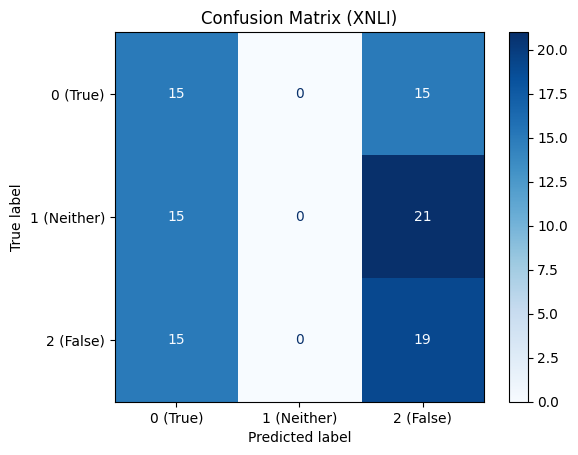

TypeError: 'module' object is not callable

In [84]:
analyze_predictions(os.path.join(output_path, "hau_xnli_prediction_dev.csv"))


In [83]:
xnli_instruction = "Is the following question True, False or Neither?"

In [50]:
# for hausa
model_function.main(
    model,
    tokenizer,
    BASE_PROMPT,
    sample_size=3,
    task_instruction=xnli_instruction,
    dataset=hau_dataset,
    csv_file_path=os.path.join(
        output_path,
        "hau_xnli_prediction_dev.csv"
    ),
    max_new_tokens=10,
    custom_instruct=False,
)

# for swahili
model_function.main(
    model,
    tokenizer,
    BASE_PROMPT,
    sample_size=3,
    task_instruction=xnli_instruction,
    dataset=swa_dataset,
    csv_file_path=os.path.join(
        output_path,
        "swa_xnli_prediction_dev.csv"
    ),
    max_new_tokens=10,
    custom_instruct=False,
)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


In [23]:
from collections import Counter
def process_likelihood(likelihood_str: str) -> List[float]:
    """
    Process a likelihood string to clean and convert it to a list of floats.
    """
    # Clean the string to remove unwanted characters
    clean_str = (
        likelihood_str.replace("tensor(", "").replace(")", "").strip()
        .replace("[[", "").replace("]]", "").strip()
        .replace(" device='cuda:0'", "").replace(" dtype=torch.float16", "").strip()
        .replace("tensor", "").strip()
    )

    # Remove any empty strings caused by extra commas
    clean_str = clean_str.replace(",,", ",")  # Remove duplicate commas if they exist

    # Convert to a list of floats
    likelihood = [
        float(x) for x in clean_str.split(",") if x.strip()
    ]  # Ensure non-empty strings are converted
    return likelihood

import math

def process_likelihood(likelihood_str):
    if likelihood_str is None or (isinstance(likelihood_str, float) and math.isnan(likelihood_str)):
        return None  # or return some default

    likelihood_str = str(likelihood_str)
    clean_str = (
        likelihood_str.replace("tensor(", "")
        .replace(")", "")
        .replace("[[", "")
        .replace("]]", "")
        .replace(" device='cuda:0'", "")
        .replace(" dtype=torch.float16", "")
        .strip()
    )
    return clean_str


def create_submission(output_path, test_flag: bool):
    """
    Creates submission files based on the provided test_flag.

    Args:
    test_flag (bool): If True, creates a test submission file; otherwise, creates a final submission file.
    """
    if test_flag:
        try:
            df1 = pd.read_csv(os.path.join(
                output_path,
                "hau_sent_prediction_dev.csv")
                 )
            df2 = pd.read_csv(os.path.join(
                output_path,
                "swa_sent_prediction_dev.csv")
            )
            df3 = pd.read_csv(os.path.join(
                output_path,
                "hau_mt_prediction_dev.csv")
                             )
            df4 = pd.read_csv(os.path.join(
                output_path,
                "swa_mt_prediction_dev.csv"))
            df5 = pd.read_csv(os.path.join(
                output_path,
                "hau_xnli_prediction_dev.csv"))
            df6 = pd.read_csv(os.path.join(
                output_path,
                "swa_xnli_prediction_dev.csv"))
        except FileNotFoundError as e:
            print(
                "Seems you have not completed all the tasks, please complete all the tasks before attempting to create your submission file"
            )
            raise e
    else:
        filename = "submission.csv"
        try:
            df1 = pd.read_csv(os.path.join(
                output_path,
                "hau_sent_prediction.csv"))
            df2 = pd.read_csv(os.path.join(
                output_path,
                "swa_sent_prediction.csv"))
            df3 = pd.read_csv(os.path.join(
                output_path,
                "hau_mt_prediction.csv"))
            df4 = pd.read_csv(os.path.join(
                output_path,
                "swa_mt_prediction.csv"))
            df5 = pd.read_csv(os.path.join(
                output_path,
                "hau_xnli_prediction.csv"))
            df6 = pd.read_csv(os.path.join(
                output_path,
                "swa_xnli_prediction.csv"))
        except FileNotFoundError as e:
            print(
                "Seems you have not completed all the tasks, please complete all the tasks before attempting to create your submission file"
            )
            raise e

    # Combine and process data
    resmt = pd.concat([df3, df4], ignore_index=True)
    res_log = pd.concat([df1, df2, df5, df6], ignore_index=True)
    res_log.drop(columns=["Response"], inplace=True)
    res_log.rename(columns={"Log-Likelihood": "Response"}, inplace=True)
    res = pd.concat([res_log, resmt], ignore_index=True)

    def process_row(row):
        if "xnli" in row["ID"] or "sent" in row["ID"]:
            likelihoods = process_likelihood(row["Response"])
            predicted_label = np.argmax(likelihoods)
            return predicted_label
        return row["Response"]  # Default for other cases

    # Update the Response column in-place
    res["Response"] = res.apply(process_row, axis=1)

    if test_flag:
        filename = os.path.join(
                output_path,
                "submission_test.csv")
        # Save the submission file
        submission = res[["ID", "Response", "Targets"]]
        submission.to_csv(filename, index=False)
    else:
        filename = os.path.join(
                output_path,
                "submission.csv")
        # Save the submission file
        submission = res[["ID", "Response"]]
        submission.to_csv(filename, index=False)
    return submission

def evaluate_zindi_by_language(df):
    from collections import defaultdict, Counter
    import numpy as np

    results = defaultdict(lambda: defaultdict(list))  # results[task][lang] = [(true, pred), ...]
    chrfs_scores = defaultdict(list)

    for _, row in df.iterrows():
        ID = row["ID"].lower()

        # --- Task detection ---
        if "sentiment" in ID or "sent" in ID:
            task = "sent"
        elif "xnli" in ID or "afrixnli" in ID:
            task = "xnli"
        elif "mt" in ID:
            task = "mt"
        else:
            continue  # skip unknown tasks

        # --- Language detection ---
        if any(x in ID for x in ["swahili", "swa", "eng-swa"]):
            lang = "swahili"
        elif any(x in ID for x in ["hausa", "hau", "eng-hau"]):
            lang = "hausa"
        else:
            lang = "unknown"

        # --- Scoring logic ---
        if task == "sent":
            labels = {
                "swahili": ["Chanya", "Wastani", "Hasi"],
                "hausa": ["Kyakkyawa", "Tsaka-tsaki", "Korau"]
            }.get(lang, [])
            if not labels:
                continue
            label_to_id = {label.lower(): i for i, label in enumerate(labels)}
            true = label_to_id.get(row["Targets"].strip().lower(), -1)
            pred = int(row["Response"])
            if true != -1:
                results[task][lang].append((true, pred))

        elif task == "xnli":
            try:
                true = int(row["Targets"])
                pred = int(row["Response"])
                results[task][lang].append((true, pred))
            except:
                continue  # skip rows with invalid labels

        elif task == "mt":
            ref = row["Targets"]
            hyp = row["Response"]
            chrfs = chrF(reference=ref, hypothesis=hyp)
            chrfs_scores[lang].append(chrfs)

    # --- Aggregation ---
    report = {}
    for task in results:
        for lang in results[task]:
            y_true, y_pred = zip(*results[task][lang])
            f1 = calculate_f1(np.array(y_true), np.array(y_pred), num_classes=3)
            report[f"{task}_{lang}"] = round(f1, 4)

    for lang in chrfs_scores:
        avg_chrfs = np.mean(chrfs_scores[lang])
        report[f"mt_{lang}"] = round(avg_chrfs, 4)

    # --- Zindi score ---
    zindi_score = np.mean(list(report.values()))
    report["zindi_score"] = round(zindi_score, 4)

    return report


# From scratch implementation of chrf
def get_char_ngrams(sentence, n):
    """Generate character n-grams from a sentence."""
    sentence = sentence.replace(" ", "")  # Remove spaces for chrF
    return [sentence[i : i + n] for i in range(len(sentence) - n + 1)]


def precision_recall(reference, hypothesis, n):
    """Calculate precision and recall for character n-grams."""
    ref_ngrams = get_char_ngrams(reference, n)
    hyp_ngrams = get_char_ngrams(hypothesis, n)

    ref_count = Counter(ref_ngrams)
    hyp_count = Counter(hyp_ngrams)

    common_ngrams = ref_count & hyp_count
    true_positives = sum(common_ngrams.values())

    precision = true_positives / max(len(hyp_ngrams), 1)
    recall = true_positives / max(len(ref_ngrams), 1)

    return precision, recall


def f_score(precision, recall, beta=1):
    """Calculate the F1 score."""
    if precision + recall == 0:
        return 0.0
    return (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)


def chrF(reference, hypothesis, max_n=6, beta=2):
    """Calculate the chrF score from scratch."""
    precisions = []
    recalls = []

    for n in range(1, max_n + 1):
        precision, recall = precision_recall(reference, hypothesis, n)
        precisions.append(precision)
        recalls.append(recall)

    avg_precision = sum(precisions) / max_n
    avg_recall = sum(recalls) / max_n

    return f_score(avg_precision, avg_recall, beta)


# From scratch implementation f1score 3 class
def calculate_f1(true_labels, pred_labels, num_classes):
    f1_scores = []

    for i in range(num_classes):
        TP = np.sum((true_labels == i) & (pred_labels == i))  # True Positives
        FP = np.sum((true_labels != i) & (pred_labels == i))  # False Positives
        FN = np.sum((true_labels == i) & (pred_labels != i))  # False Negatives

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0

        # Calculate F1 score
        f1 = (
            2 * (precision * recall) / (precision + recall)
            if (precision + recall) > 0
            else 0
        )
        f1_scores.append(f1)

    macro_f1 = np.mean(f1_scores)

    return macro_f1


In [124]:
score_test = create_submission(output_path=output_path, test_flag=True)

In [125]:
score_test

,ID,Response,Targets
0,ID_6aba33a1_sentiment_ dev_hausa,0,Kyakkyawa
1,ID_ce64d307_sentiment_ dev_hausa,0,Tsaka-tsaki
2,ID_2efc9515_sentiment_ dev_hausa,0,Tsaka-tsaki
3,ID_dfb02831_sentiment_ dev_swahili,0,Wastani
4,ID_ad1d9888_sentiment_ dev_swahili,0,Wastani
...,...,...,...
201,ID_463ee0f1_dev_mt_eng-swa,"OAD, Hausa",simulizi za majonzi: october 2009
202,ID_70f2f4f1_dev_mt_eng-swa,NaN,money na hawana tena ulazima wa kutembea na ma...
203,ID_03499807_dev_mt_eng-swa,NaN,chunguza visiwa vya canary na utawapenda.
204,ID_5ed7e4be_dev_mt_eng-swa,wa ka san cewa shi ne mai taimakon alumma da y...,tofauti ni kubwa kuliko unavyoanza kufikiri......


In [129]:
score_test = score_test.dropna(axis=1, how='all')


In [131]:
score_test

,ID,Response,Targets
0,ID_6aba33a1_sentiment_ dev_hausa,0,Kyakkyawa
1,ID_ce64d307_sentiment_ dev_hausa,0,Tsaka-tsaki
2,ID_2efc9515_sentiment_ dev_hausa,0,Tsaka-tsaki
3,ID_dfb02831_sentiment_ dev_swahili,0,Wastani
4,ID_ad1d9888_sentiment_ dev_swahili,0,Wastani
...,...,...,...
201,ID_463ee0f1_dev_mt_eng-swa,"OAD, Hausa",simulizi za majonzi: october 2009
202,ID_70f2f4f1_dev_mt_eng-swa,NaN,money na hawana tena ulazima wa kutembea na ma...
203,ID_03499807_dev_mt_eng-swa,NaN,chunguza visiwa vya canary na utawapenda.
204,ID_5ed7e4be_dev_mt_eng-swa,wa ka san cewa shi ne mai taimakon alumma da y...,tofauti ni kubwa kuliko unavyoanza kufikiri......


In [130]:
score_report = evaluate_zindi_by_language(score_test)
score_report

AttributeError: 'float' object has no attribute 'replace'

In [56]:
# 1. How many rows of xnli_hausa?
df = score_test
df[(df["ID"].str.contains("xnli", case=False) | df["ID"].str.contains("afrixnli", case=False)) &
   (df["ID"].str.contains("hau", case=False))]


,ID,Response,Targets
6,ID_648d37ff_dev_afrixnli_hau,1,0
7,ID_f96a39cb_dev_afrixnli_hau,1,0
8,ID_99a61e3d_dev_afrixnli_hau,1,2
